<a href="https://colab.research.google.com/github/tcurtis714/lis4693/blob/main/lab-7/lab7_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7: Sentiment Analysis

## Import Libraries

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

## Load Data

In [4]:
import requests
import io

url = "https://raw.githubusercontent.com/tcurtis714/lis4693/refs/heads/main/lab-7/bbc-news-data.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

df = pd.read_csv(io.StringIO(text), sep='\t')
print(df.head())

   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  002.txt   Dollar gains on Greenspan speech   
2  business  003.txt  Yukos unit buyer faces loan claim   
3  business  004.txt  High fuel prices hit BA's profits   
4  business  005.txt  Pernod takeover talk lifts Domecq   

                                             content  
0   Quarterly profits at US media giant TimeWarne...  
1   The dollar has hit its highest level against ...  
2   The owners of embattled Russian oil giant Yuk...  
3   British Airways has blamed high fuel prices f...  
4   Shares in UK drinks and food firm Allied Dome...  


## Create new dataframe with 'filename' and 'content' fields

In [5]:
df_subset = df[['filename', 'content']].copy()

- the 'text' field for this dataset is the 'content' column. It contains the full text of each article in the dataset

## Remove non-alphabet characters

In [6]:
df_subset['content'] = df_subset['content'].str.replace("[^a-zA-Z#]", "   ")

## Convert to lower case

In [7]:
df_subset['content'] = df_subset['content'].str.casefold()
print(df_subset.head(10))

  filename                                            content
0  001.txt   quarterly profits at us media giant timewarne...
1  002.txt   the dollar has hit its highest level against ...
2  003.txt   the owners of embattled russian oil giant yuk...
3  004.txt   british airways has blamed high fuel prices f...
4  005.txt   shares in uk drinks and food firm allied dome...
5  006.txt   japan's economy teetered on the brink of a te...
6  007.txt   the us created fewer jobs than expected in ja...
7  008.txt   india, which attends the g7 meeting of seven ...
8  009.txt   ethiopia produced 14.27 million tonnes of cro...
9  010.txt   a us government claim accusing the country's ...


## Generate Sentiment Polarity Scores

In [8]:
df1 = pd.DataFrame()
df1['filename'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

In [9]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['content']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'filename': row['filename'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
   filename sentiment_type  sentiment_score
3   001.txt       compound           0.9950
7   002.txt       compound           0.9347
11  003.txt       compound          -0.8860
15  004.txt       compound           0.9790
19  005.txt       compound           0.6652
23  006.txt       compound           0.6204
27  007.txt       compound           0.9547
31  008.txt       compound          -0.6795
35  009.txt       compound          -0.2023
39  010.txt       compound           0.2263


In [10]:
df_output = pd.merge(df, t_df_cleaned, on='filename', how='inner')
print(df_output.head(10))

   category filename                              title  \
0  business  001.txt  Ad sales boost Time Warner profit   
1  business  001.txt  Ad sales boost Time Warner profit   
2  business  001.txt  Ad sales boost Time Warner profit   
3  business  001.txt  Ad sales boost Time Warner profit   
4  business  001.txt  Ad sales boost Time Warner profit   
5  business  002.txt   Dollar gains on Greenspan speech   
6  business  002.txt   Dollar gains on Greenspan speech   
7  business  002.txt   Dollar gains on Greenspan speech   
8  business  002.txt   Dollar gains on Greenspan speech   
9  business  002.txt   Dollar gains on Greenspan speech   

                                             content sentiment_type  \
0   Quarterly profits at US media giant TimeWarne...       compound   
1   Quarterly profits at US media giant TimeWarne...       compound   
2   Quarterly profits at US media giant TimeWarne...       compound   
3   Quarterly profits at US media giant TimeWarne...       compoun

## Vizualize Sentiment Analysis Output

In [11]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,10387.000000
mean,0.402121
std,0.790898
min,-0.999900
25%,-0.421500
50%,0.921100
75%,0.983200
max,1.000000


- The min score of -0.99 indicates the polarity of the most negative score is strongly negative
- The max score of +1.0 indicates the polarity of the most postive score is strongly positive
- The mean value of +0.4 indicates that the average polarity of sentiment across all responses is neutral

<Axes: title={'center': 'sentiment_score'}, xlabel='Category', ylabel='Mean Sentiment Score'>

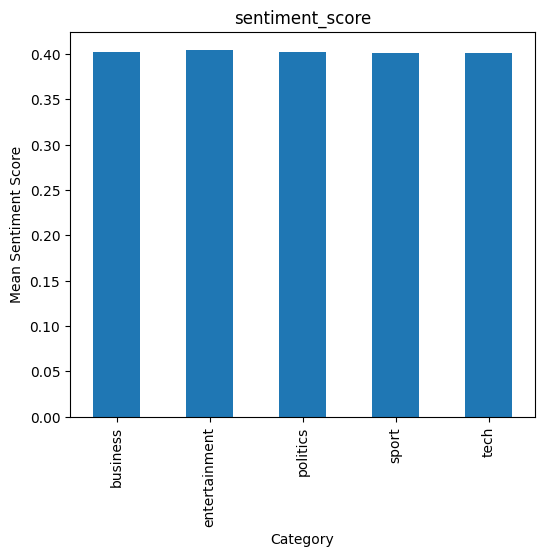

In [12]:
dfg = df_output.groupby(['category'])['sentiment_score'].mean()
dfg.plot(kind='bar', title='sentiment_score', ylabel='Mean Sentiment Score',
         xlabel='Category', figsize=(6, 5))

### Bar plot for 'category' using Altair

In [13]:
import altair as alt

# Prepare data for mean sentiment score by province
dfg_category = df_output.groupby('category')['sentiment_score'].mean().reset_index()

# Create the Altair bar chart for Sentiment Score by Province
chart_category = alt.Chart(dfg_category).mark_bar().encode(
    x=alt.X('category:N', title='Category', sort='-y'), # Sort by sentiment score
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score'),
    color=alt.Color('category:N', legend=alt.Legend(title="Category")),
    tooltip=['category', 'sentiment_score']
).properties(
    title='Mean Sentiment Score by Category'
).interactive()

chart_category

alt.Chart(...)

- The bar plots show that all categories of news had a similar amount of neutral incidents.
- The 'entertainment' category had the most amount of neutral incidents by a very small amount

## Reflection

The only issue I had was loading the dataset and converting it to a dataframe. The data is tab separated but the default separator for pd.read_csv is comma. A quick google search is all it took to identify and fix the problem. After that, everything went smoothly.

Sentiment Analysis could help in cybersecurity by analyzing the tone of text-based threats such as emails. Phishing emails often take negative emotional tones to threaten or scare the recipient into clicking on a link. Sentiment analysis could identify and flag certain language.